# Sales Performance Analysis

## Business Problem

A retail company wants to better understand its sales performance across products, customers, and regions. The objective of this project is to analyze sales performance, identify key trends, evaluate business performance, and provide actionable recommendations to improve sales and profitability.

---
## Objectives

The analysis aims to answer the following business questions:

- How are sales and profits performing over time?
- Which products and categories generate the highest revenue and profit?
- Which customer segments contribute the most to sales?
- Which regions perform best and which require improvement?
- How do discounts affect profitability?
- What business recommendations can be made based on the findings?

---
## Dataset

- Source: Sample Superstore Dataset
- Records: 9,994
- Features: 21

---
## Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In this section, we will import the sales dataset and create a Pandas DataFrame for analysis.

In [4]:
df = pd.read_csv("../Data/Superstore.csv", encoding="latin1")

In [5]:
df.shape

(9994, 21)

The dataset contains **9,994 rows** and **21 columns**, providing information about orders, customers, products, sales, discounts, and profits.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

The dataset contains no missing values. Order Date and Ship Date are currently stored as text and will be converted to datetime format during the data preparation stage.

## Data Quality Check

Before analyzing the data, we will check for duplicates and missing values to ensure the dataset is reliable.

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

The dataset was checked for duplicate records and missing values. No duplicates or missing values were identified, indicating that the dataset is complete and ready for further analysis.

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

Both date columns were successfully converted to datetime format, enabling time-based analysis.

## Exploratory Data Analysis

The following analysis explores the dataset to understand sales performance, identify patterns, detect anomalies, and generate business insights.

In [11]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


### Initial Observations

- The dataset contains 9,994 transactions.
- Sales vary considerably, ranging from **$0.44** to **$22,638.48**, indicating the presence of very large orders.
- Profit ranges from a loss of **$6,599.98** to a gain of **$8,399.98**, suggesting that some transactions are highly unprofitable.
- These observations motivate a deeper investigation into potential outliers.

<Axes: >

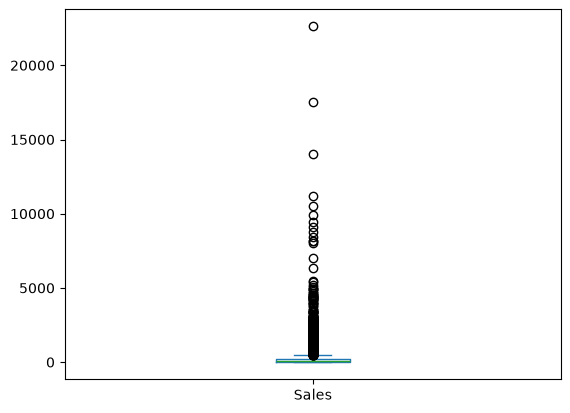

In [12]:
df["Sales"].plot(kind="box")

<Axes: >

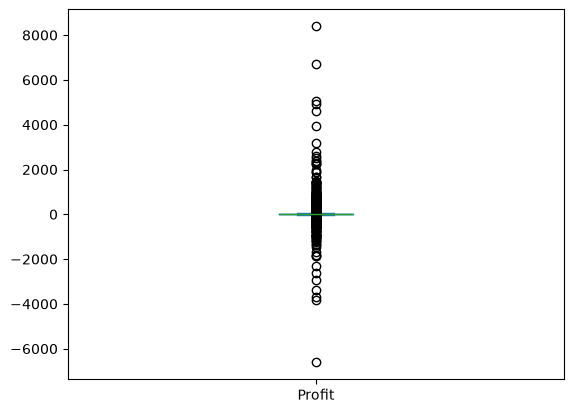

In [13]:
df["Profit"].plot(kind="box")


Both Sales and Profit contain several extreme values. While these observations fall outside the typical range, they may represent legitimate business transactions rather than data entry errors. Therefore, the outliers will be investigated further instead of being removed.

In [14]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sales_outliers = df[(df["Sales"] < lower_bound) | (df["Sales"] > upper_bound)]

sales_outliers.shape

(1167, 21)

In [15]:
sales_outliers["Sales"].describe()

count     1167.000000
mean      1266.052104
std       1419.107804
min        499.168000
25%        631.960000
50%        866.400000
75%       1346.502500
max      22638.480000
Name: Sales, dtype: float64

In [16]:
sales_outliers["Category"].value_counts()

Category
Furniture          467
Technology         400
Office Supplies    300
Name: count, dtype: int64

### Interpretation

A total of **1,167** sales outliers were identified. These outliers are distributed across all three product categories, indicating that unusually large sales are not limited to a single category. Because these transactions appear to represent valid business activity, they will be retained for further analysis.

In [17]:
Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)

IQR = Q3 - Q1

profit_outliers = df[
    (df["Profit"] < Q1 - 1.5 * IQR) |
    (df["Profit"] > Q3 + 1.5 * IQR)
]

profit_outliers.shape

(1881, 21)

In [18]:
profit_outliers["Category"].value_counts()

Category
Office Supplies    685
Furniture          627
Technology         569
Name: count, dtype: int64

In [19]:
profit_outliers["Profit"].describe()

count    1881.000000
mean      102.207906
std       532.477102
min     -6599.978000
25%       -58.305600
50%        93.698800
75%       178.800000
max      8399.976000
Name: Profit, dtype: float64

### Interpretation

A total of **1,881** profit outliers were detected across all product categories. The presence of both large positive and negative profits suggests substantial variability in transaction profitability. These observations warrant further investigation to identify the factors influencing profit.

The exploratory analysis identified considerable variation in sales and profitability across transactions. To better understand the company's overall performance, the next section summarizes the key business metrics before examining trends across time, products, and regions.


### KPI Summary

In [20]:
sales_sum = df["Sales"].sum()
profit_sum = df["Profit"].sum()
order_count = df["Order ID"].nunique()
customer_count = df["Customer ID"].nunique()
aov = sales_sum / order_count

print(f"Total Sales: ${sales_sum:,.2f}")
print(f"Total Profit: ${profit_sum:,.2f}")
print(f"Number of Orders: {order_count}")
print(f"Number of Customers: {customer_count}")
print(f"Average Order Value: ${aov:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Number of Orders: 5009
Number of Customers: 793
Average Order Value: $458.61


### Key Findings

- The company generated **$2.30 million** in total sales.
- Total profit reached approximately **$286,000**.
- A total of **5,009** unique orders were placed by **793** customers.
- The average order value was **$458.61**, indicating relatively high-value transactions.

These KPIs provide an overall view of the company's performance and establish a baseline for the analyses that follow.

## Sales Trend Over Time

This analysis examines how total sales changed between 2014 and 2017 to identify growth patterns, seasonality, and significant fluctuations over time.

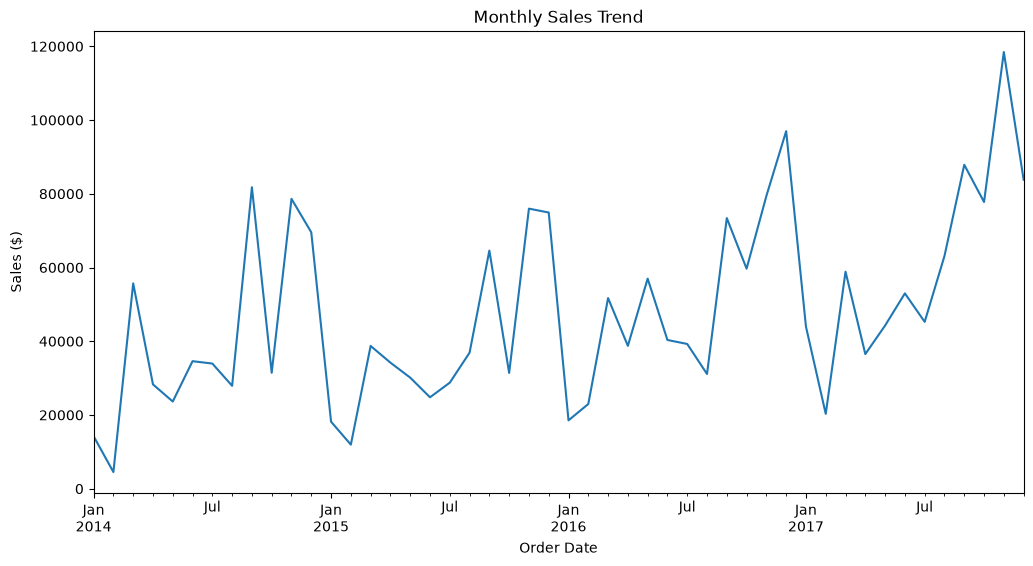

In [21]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)
monthly_sales.plot(
    figsize=(12, 6),
    title="Monthly Sales Trend",
    xlabel="Order Date",
    ylabel="Sales ($)"
)

plt.show()

### Business Insights

- Sales showed a clear upward trend between **2014 and 2017**, indicating continuous business growth.
- Sales consistently peaked during the **fourth quarter** of each year, suggesting a strong seasonal effect.
- **January** recorded the lowest sales across all years, indicating a recurring period of weaker demand.
- Mid-year sales remained relatively stable before increasing toward year-end.

These findings suggest that the business experiences strong seasonal demand during the fourth quarter. Management may consider increasing inventory levels, staffing, and marketing efforts before year-end while investigating the factors contributing to weaker sales in January.

### Category Analysis

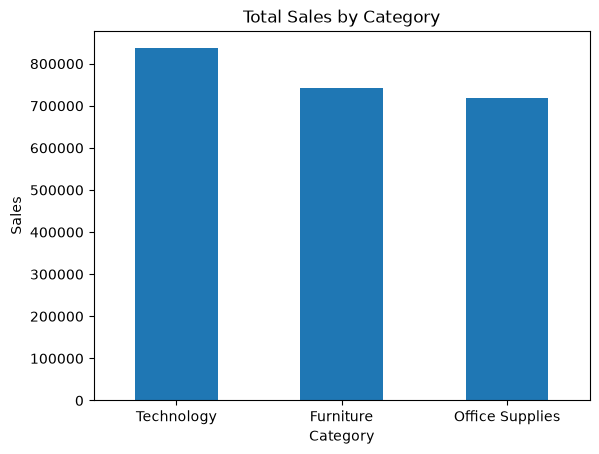

In [22]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False))

category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

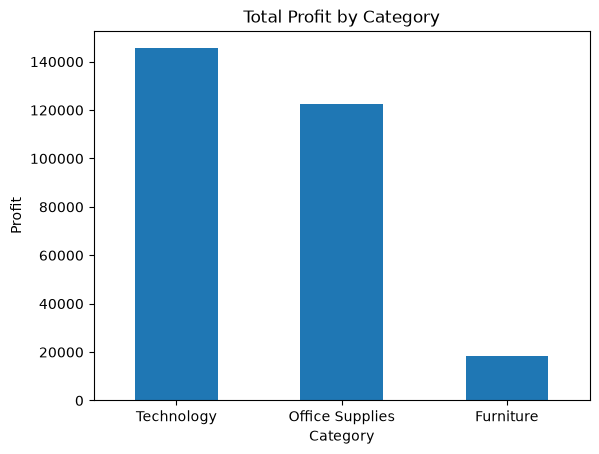

In [23]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False))
category_profit.plot(kind="bar")
plt.title("Total Profit by Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

### Interpretation

Technology is the strongest-performing category, generating both the highest total sales and the highest total profit.

Although Furniture generates more sales than Office Supplies, it produces less total profit. This indicates that higher revenue does not necessarily translate into higher profitability and suggests that further investigation into its individual sub-categories is warranted.

### Sub-category Analysis

In [ ]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False))

sub_category_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

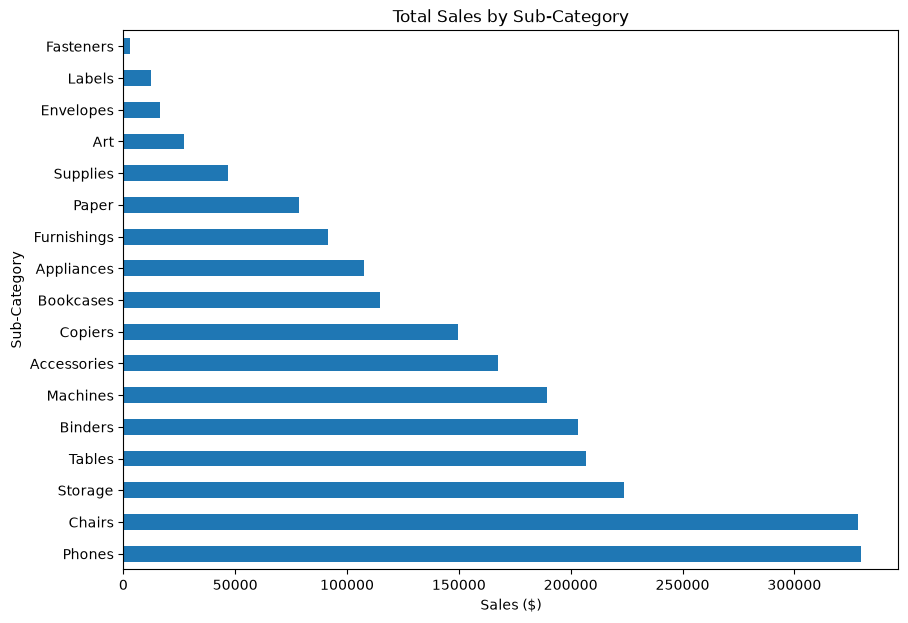

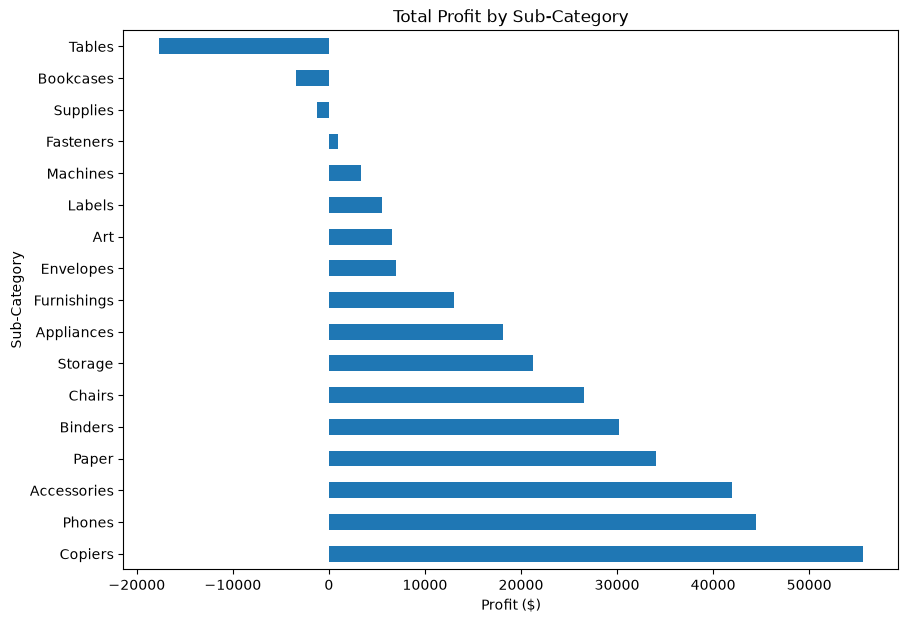

In [26]:
subcategory_sales.plot(
    kind="barh",
    figsize=(10, 7),
    title="Total Sales by Sub-Category",
    xlabel="Sales ($)",
)
plt.show()
sub_category_profit.plot(
    kind="barh",
    figsize=(10, 7),
    title="Total Profit by Sub-Category",
    xlabel="Profit ($)",
)

plt.show()

### Business Insights

- Phones generated the highest total Sales among all sub-categories.
- Copiers produced the highest total Profit despite ranking only eighth in Sales.
- Tables ranked fourth in Sales but generated the lowest Profit, making them the most significant profitability concern.

Because Tables combine strong customer demand with poor financial performance, the following section investigates the factors contributing to these losses.

### Investigating the Low Profitability of Tables

In [27]:
tables_df = df[df["Sub-Category"] == "Tables"]
tables_df["Profit"].describe()

count     319.000000
mean      -55.565771
std       230.565006
min     -1862.312400
25%      -122.829300
50%       -31.372200
75%        33.851700
max       629.010000
Name: Profit, dtype: float64

In [28]:
(tables_df["Profit"] < 0).sum()

np.int64(203)

Out of 319 Table transactions, 203 resulted in a loss.

In [29]:
tables_df["Discount"].describe()

count    319.000000
mean       0.261285
std        0.169622
min        0.000000
25%        0.200000
50%        0.300000
75%        0.400000
max        0.500000
Name: Discount, dtype: float64

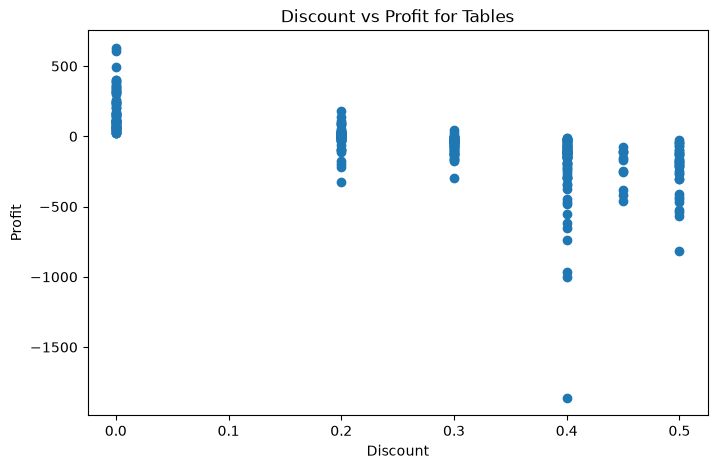

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(
    tables_df["Discount"],
    tables_df["Profit"])

plt.title("Discount vs Profit for Tables")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [31]:
tables_df[["Discount", "Profit"]].corr()


,Discount,Profit
Discount,1.00000,-0.67177
Profit,-0.67177,1.00000


In [32]:
subcategory_discount_profit = df.groupby("Sub-Category")[["Discount", "Profit"]].mean()
subcategory_discount_profit

,Discount,Profit
Sub-Category,,
Accessories,0.078452,54.111788
Appliances,0.166524,38.922758
Art,0.074874,8.200737
Binders,0.372292,19.843574
Bookcases,0.211140,-15.230509
Chairs,0.170178,43.095894
Copiers,0.161765,817.909190
Envelopes,0.080315,27.418019
Fasteners,0.082028,4.375660


### Additional Observation

Although several sub-categories receive relatively high discounts, Tables and Bookcases remain unprofitable. This suggests that discounting does not affect all products equally and that pricing strategies should be tailored to the characteristics of each sub-category.

The analysis above focused on product performance. The next section examines whether business performance also varies across different geographic regions.

### Regional Performance

In [33]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [34]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
region_profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

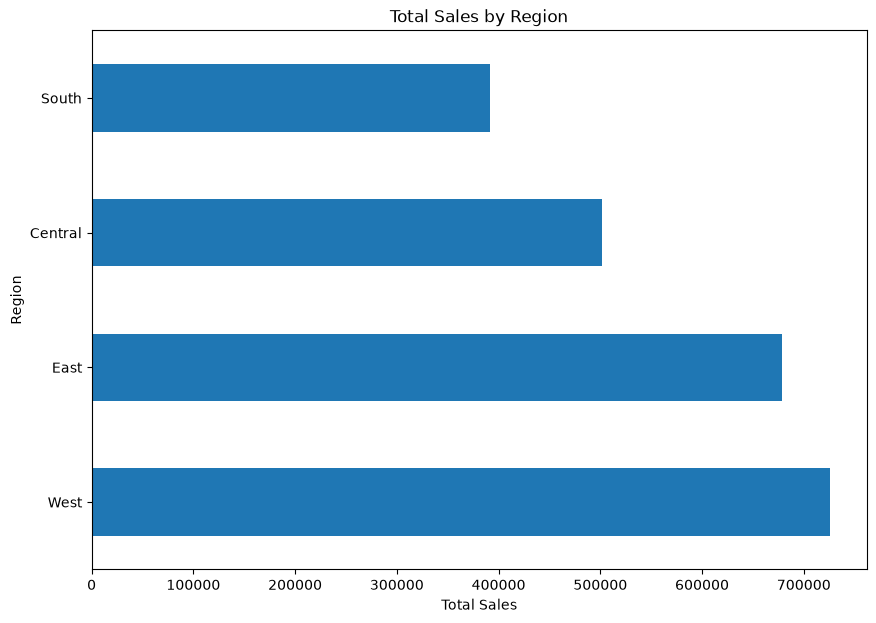

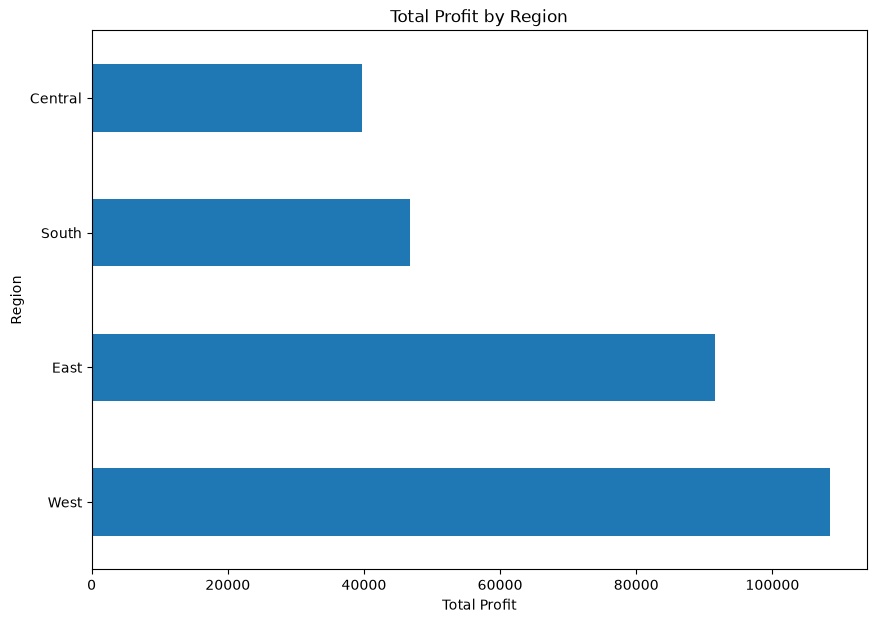

In [35]:
region_sales.plot(
    kind="barh",
    figsize=(10, 7),
    title="Total Sales by Region",
    xlabel="Total Sales",
    ylabel="Region"
)
plt.show()

region_profit.plot(
    kind="barh",
    figsize=(10, 7),
    title="Total Profit by Region",
    xlabel="Total Profit",
    ylabel="Region"
)
plt.show()



### Business Insights

- The West region generated the highest total Sales and Profit.
- The Central region generated higher Sales than the South region but lower Profit, indicating weaker profitability despite its sales volume.
- The Central region therefore warrants further investigation to identify factors contributing to its lower profitability.

In [36]:
state_profit = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values(ascending=True)
)
state_profit

State
Texas                  -25729.3563
Ohio                   -16971.3766
Pennsylvania           -15559.9603
Illinois               -12607.8870
North Carolina          -7490.9122
Colorado                -6527.8579
Tennessee               -5341.6936
Arizona                 -3427.9246
Florida                 -3399.3017
Oregon                  -1190.4705
Wyoming                   100.1960
West Virginia             185.9216
North Dakota              230.1497
South Dakota              394.8283
Maine                     454.4862
Idaho                     826.7231
Kansas                    836.4435
District of Columbia     1059.5893
New Mexico               1157.1161
Iowa                     1183.8119
New Hampshire            1706.5028
South Carolina           1769.0566
Montana                  1833.3285
Nebraska                 2037.0942
Louisiana                2196.1023
Vermont                  2244.9783
Utah                     2546.5335
Mississippi              3172.9762
Nevada        

In [37]:
central_region_df = df[df["Region"] == "Central"]

central_states = central_region_df.groupby("State")[["Sales","Profit"]].sum().sort_values("Profit" ,ascending=False)
central_states

,Sales,Profit
State,,
Michigan,76269.6140,24463.1876
Indiana,53555.3600,18382.9363
Minnesota,29863.1500,10823.1874
Wisconsin,32114.6100,8401.8004
Missouri,22205.1500,6436.2105
Oklahoma,19683.3900,4853.9560
Nebraska,7464.9300,2037.0942
Iowa,4579.7600,1183.8119
Kansas,2914.3100,836.4435


Within the Central region, several states recorded substantial losses, with Texas and Illinois among the largest contributors. This suggests that the Central region's weak profitability is concentrated in specific states rather than being evenly distributed across the region.

### Customer Segment Analysis

In [38]:
customer_segment= df.groupby("Segment")[["Sales", "Profit"]].sum().sort_values("Profit",ascending=False)
customer_segment

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [40]:
customer_segment["Profit Margin (%)"] = (
    customer_segment["Profit"] / customer_segment["Sales"] * 100
).round(2)

customer_segment

,Sales,Profit,Profit Margin (%)
Segment,,,
Consumer,1.161401e+06,134119.2092,11.55
Corporate,7.061464e+05,91979.1340,13.03
Home Office,4.296531e+05,60298.6785,14.03


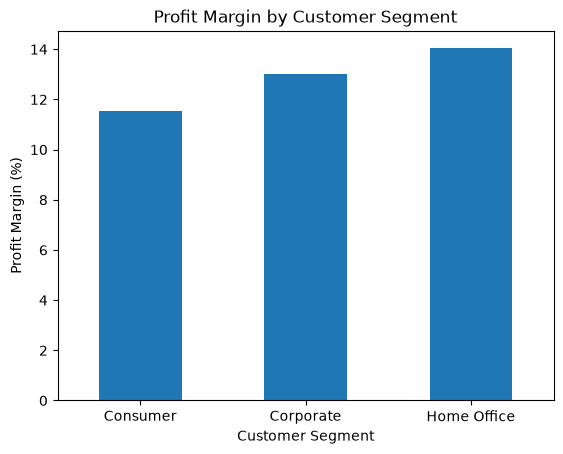

In [41]:
customer_segment["Profit Margin (%)"].plot(kind="bar")
plt.title("Profit Margin by Customer Segment")
plt.ylabel("Profit Margin (%)")
plt.xlabel("Customer Segment")
plt.xticks(rotation=0)
plt.show()

### Business Insights

- Consumer generated the highest total Sales and Profit but had the lowest Profit Margin at 11.55%.
- Home Office generated the lowest total Sales among the three segments but achieved the highest Profit Margin at 14.03%.
- This indicates that higher sales volume does not necessarily translate into higher profitability.
- The stronger profitability of the Home Office segment warrants further investigation into its purchasing behavior and pricing strategy.

# Business Recommendations

The following recommendations are based on the findings of the exploratory data analysis and are intended to improve profitability and support data-driven business decisions.

## 1. Review the Discount Strategy for Tables

**Evidence**

- Tables ranked 4th in total Sales but generated the lowest total Profit.
- 203 out of 319 Table transactions (63.6%) resulted in a loss.
- Average discount for Tables was 26.1%.
- Discount and Profit showed a moderately strong negative correlation (-0.672).

**Recommendation**

Review the current discount strategy for Tables. Rather than applying blanket discounts, implement targeted promotional campaigns and establish minimum profit margin thresholds to reduce losses while maintaining sales performance.

## 2. Improve Profitability Across Customer Segments

**Evidence**

- Home Office achieved the highest Profit Margin (14.03%).
- Consumer generated the highest Sales and Profit but had the lowest Profit Margin (11.55%).

**Recommendation**

Analyze the purchasing behavior and pricing strategy of the Home Office segment to identify practices that could improve profitability in the Consumer and Corporate segments.

## 3. Expand High-Profit Technology Products

**Evidence**

- Technology generated the highest Sales and Profit.
- Copiers produced the highest total Profit despite ranking only eighth in Sales.

**Recommendation**

Consider expanding marketing and sales efforts for high-performing Technology products, particularly Copiers, to capitalize on their strong profitability.

## 4. Prepare for Seasonal Demand

**Evidence**

- Sales increased steadily between 2014 and 2017.
- Sales consistently peaked during the fourth quarter.
- January recorded the lowest sales each year.

**Recommendation**

Increase inventory and marketing efforts before the fourth quarter to meet seasonal demand, while developing promotional campaigns to improve sales performance during January.

# Conclusion

This analysis examined sales performance between 2014 and 2017 to identify the key drivers of revenue and profitability. The findings showed that while the company experienced consistent sales growth over time, profitability varied considerably across products, regions, and customer segments. The investigation identified Tables as the primary profitability concern due to frequent losses and a moderately strong negative relationship between discounts and profit. Overall, the analysis provides actionable insights to support pricing decisions, marketing strategies, and future business planning.